# Adult income analysis (interactive version)

Same steps as `src/main.py`, cell by cell. The script is the reference implementation that the
tests and CI run; this notebook is for exploring the intermediate results.

1. Import the dataset
2. Inspect the data
3. Basic filtering and grouping
4. Explore a machine learning algorithm
5. Visualisation
7. Pandas vs Polars

### 1. Import the dataset
The UCI file has no header, a space after every comma, `?` for missing values and a trailing blank line.

In [1]:
import urllib.request
from pathlib import Path

import pandas as pd
import polars as pl

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
COLS = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation",
        "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"]
NUM_COLS = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
DATA = Path("../data/adult.data")

if not DATA.exists():
    DATA.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(URL, DATA)

df_pd = pd.read_csv(DATA, header=None, names=COLS, na_values="?", skipinitialspace=True)

# polars needs the same cleaning done by hand: strip spaces, '?' -> null, cast numbers, drop the blank line
df_pl = (
    pl.read_csv(DATA, has_header=False, new_columns=COLS, infer_schema=False)
    .with_columns(pl.col(pl.String).str.strip_chars().replace("?", None))
    .with_columns(pl.col(NUM_COLS).cast(pl.Int64))
    .filter(~pl.all_horizontal(pl.all().is_null()))
)
df_pd.shape, df_pl.shape

((32561, 15), (32561, 15))

### 2. Inspect the data

In [2]:
df_pd.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df_pd.describe().round(2)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [5]:
print("missing values per column:\n", df_pd.isna().sum()[lambda s: s > 0], sep="")
print("\nduplicate rows:", df_pd.duplicated().sum())

missing values per column:
workclass         1836
occupation        1843
native_country     583
dtype: int64

duplicate rows: 24


In [6]:
df_pd = df_pd.drop_duplicates().reset_index(drop=True)
df_pl = df_pl.unique(keep="first", maintain_order=True)
len(df_pd), len(df_pl)

(32537, 32537)

### 3. Basic filtering and grouping

In [7]:
overtime = df_pd[df_pd["hours_per_week"] > 40]
print(f"people working more than 40 h/week: {len(overtime)} of {len(df_pd)}")
overtime["income"].value_counts(normalize=True).round(3)

people working more than 40 h/week: 9576 of 32537


income
<=50K    0.597
>50K     0.403
Name: proportion, dtype: float64

In [8]:
# per education level: count, mean hours, mean capital gain, share earning >50K
by_edu = (
    df_pd.assign(high_income=df_pd["income"].eq(">50K"))
    .groupby("education")
    .agg(count=("age", "size"), mean_hours_per_week=("hours_per_week", "mean"),
         mean_capital_gain=("capital_gain", "mean"), share_high_income=("high_income", "mean"))
    .sort_values("share_high_income", ascending=False)
)
by_edu.round(3)

,count,mean_hours_per_week,mean_capital_gain,share_high_income
education,,,,
Doctorate,413,46.973,4770.145,0.741
Prof-school,576,47.425,10414.417,0.734
Masters,1722,43.833,2564.052,0.557
Bachelors,5353,42.614,1756.956,0.415
Assoc-voc,1382,41.611,715.051,0.261
Assoc-acdm,1067,40.504,640.399,0.248
Some-college,7282,38.869,599.564,0.190
HS-grad,10494,40.575,577.185,0.160
12th,433,35.781,284.088,0.076


In [9]:
# the same with polars
df_pl.group_by("education").agg(
    pl.len().alias("count"),
    pl.col("hours_per_week").mean().alias("mean_hours_per_week"),
    pl.col("capital_gain").mean().alias("mean_capital_gain"),
    (pl.col("income") == ">50K").mean().alias("share_high_income"),
).sort("share_high_income", descending=True)

education,count,mean_hours_per_week,mean_capital_gain,share_high_income
str,u32,f64,f64,f64
"""Doctorate""",413,46.973366,4770.145278,0.74092
"""Prof-school""",576,47.425347,10414.416667,0.734375
"""Masters""",1722,43.832753,2564.051684,0.556911
"""Bachelors""",5353,42.614048,1756.955726,0.414908
"""Assoc-voc""",1382,41.610709,715.051375,0.261216
…,…,…,…,…
"""9th""",514,38.044747,342.089494,0.052529
"""11th""",1175,33.925957,215.097872,0.051064
"""5th-6th""",332,38.849398,176.551205,0.048193


### 4. Explore a machine learning algorithm
The target is binary, so start with logistic regression. Numeric columns are scaled, text columns one-hot encoded.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df_pd.drop(columns=["income"])
y = df_pd["income"].eq(">50K").astype(int)
cat_cols = [c for c in X.columns if c not in NUM_COLS]

pre = ColumnTransformer([("num", StandardScaler(), NUM_COLS),
                         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test), target_names=["<=50K", ">50K"]))

/opt/datadog-packages/datadog-apm-library-python/3.18.1/ddtrace_pkgs/site-packages-ddtrace-py3.12-manylinux2014/ddtrace/internal/module.py:313: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  self.loader.exec_module(module)


              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.74      0.63      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508



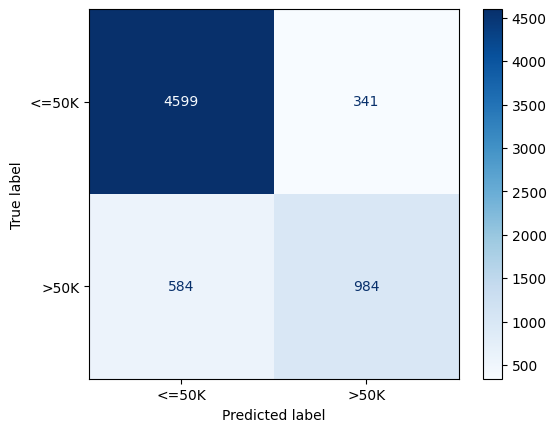

In [11]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["<=50K", ">50K"], cmap="Blues");

### 5. Visualisation

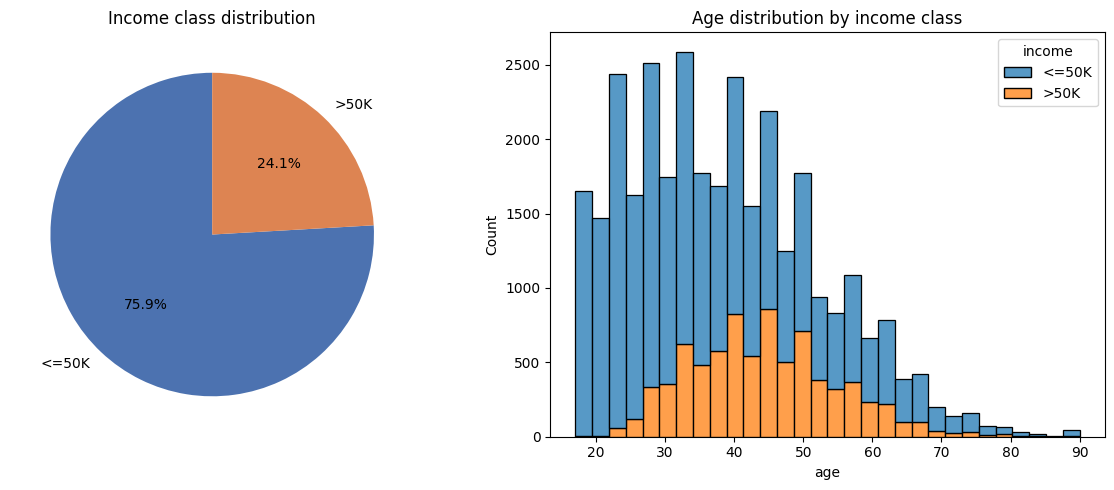

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
counts = df_pd["income"].value_counts()
ax1.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90, colors=["#4C72B0", "#DD8452"])
ax1.set_title("Income class distribution")
sns.histplot(data=df_pd, x="age", hue="income", bins=30, multiple="stack", ax=ax2)
ax2.set_title("Age distribution by income class")
plt.tight_layout()

### 7. Pandas vs Polars
Same operations, best of 5 runs. Filter and group-by run on the data repeated 50 times (1.6 M rows).

In [13]:
import time

def best_ms(fn, repeats=5):
    times = []
    for _ in range(repeats):
        t = time.perf_counter(); fn(); times.append((time.perf_counter() - t) * 1000)
    return min(times)

big_pd, big_pl = pd.concat([df_pd] * 50, ignore_index=True), pl.concat([df_pl] * 50)
ops = {
    "read_csv (32k rows)": (
        lambda: pd.read_csv(DATA, header=None, names=COLS, na_values="?", skipinitialspace=True),
        lambda: pl.read_csv(DATA, has_header=False, new_columns=COLS, infer_schema=False)),
    "filter hours>40 (1.6M rows)": (
        lambda: big_pd[big_pd["hours_per_week"] > 40],
        lambda: big_pl.filter(pl.col("hours_per_week") > 40)),
    "group_by education (1.6M rows)": (
        lambda: big_pd.groupby("education")["hours_per_week"].mean(),
        lambda: big_pl.group_by("education").agg(pl.col("hours_per_week").mean())),
}
bench = pd.DataFrame([(k, best_ms(f_pd), best_ms(f_pl)) for k, (f_pd, f_pl) in ops.items()],
                     columns=["operation", "pandas_ms", "polars_ms"])
bench["speedup"] = bench["pandas_ms"] / bench["polars_ms"]
bench.round(1)

,operation,pandas_ms,polars_ms,speedup
0,read_csv (32k rows),28.6,3.2,9.0
1,filter hours>40 (1.6M rows),52.9,13.0,4.1
2,group_by education (1.6M rows),63.0,11.3,5.6


Polars wins on every operation and the gap grows with the size of the data: the group-by runs in parallel on all cores while pandas is single-threaded.

`src/main.py` runs the same comparison with a heavier group-by (four aggregations at once), which is where the difference is largest (about 40x on this machine).